# Hafta 07 — Karma Tabloları & Sözlükler (Hash Tables & HashMaps)

### Algoritma: İki Toplam (Two Sum) · O(n²) → O(n) Dönüşümü

---

## Bu Hafta Ne Öğreneceğiz?

Bu hafta, bilgisayar biliminin en zarif icatlarından birine bakıyoruz: **karma tablosu (hash table)**. Python'daki `dict`, Java'daki `HashMap`, JavaScript'teki `Object` — hepsi bu fikrin birer yansıması. Arama süresini O(n)'den O(1)'e çekiyor; bu basit görünse de modern yazılımın altında yatan devrimlerden biri.

### Öğrenme Hedefleri

1. **Karma fonksiyonu ya da özet algoritması (hash function)** nedir, neden ihtiyacımız var, "iyi" bir hash fonksiyonu neye benzer?
2. **Çarpışma (collision)** kavramını anlamak ve iki temel çözüm — **zincirleme (chaining)** ve **açık adresleme (open addressing)** — arasındaki farkı kavramak.
3. Sıfırdan bir `HashTable` sınıfı yazarak Python'un `dict`'inin içinde ne olduğunu görmek.
4. **Yük faktörü (load factor)** ve **yeniden boyutlandırma (rehashing)** mantığını kavramak.
5. **Two Sum** problemini O(n²) brute-force yerine O(n)'de çözerek hashmap'in gerçek gücünü hissetmek.

### Önceki Haftalarla Bağlantı

- **Hafta 3 (Dizi/Array):** O(1) indeksle erişim ama aramada O(n).
- **Hafta 5 (Bağlı Liste/Linked List):** Eklemede O(1), aramada yine O(n).
- **Hafta 6 (İkili Arama Ağacı/BST):** Aramada O(log n) — iyi ama yeterli değil.
- **Bu Hafta:** Aramada **O(1)**. Evet, ortalamada. Nasıl?

> 💡 **Ana Fikir:** *Aramayı hesaplamaya çevirirsen, aramak zorunda kalmazsın.*


## 1) Sezgi: Telefon Rehberi, Kütüphane ve Otel Odaları

### Senaryo 1: Dedenizin Telefon Rehberi

1970'lere gidelim. Dedeniz birine ulaşmak istiyor, elinde kalın bir telefon rehberi var. Alfabetik sıralı — yani **binary search (ikili arama)** yapabilir, O(log n). Fena değil. Ama düşün: rehberde **her ismin karşısına bir "raf numarası" yazan bir formül** olsaydı? "Ahmet" girdisi için formül `182` desin; sen de doğrudan 182. sayfaya bakasın. Arama yok. Direkt **hesaplayıp** gidiyorsun.

İşte karma tablosunun sezgisi tam bu:

> **Anahtarı (key) bir sayıya çeviren bir fonksiyon bul; o sayıyı dizi indeksi olarak kullan.**

### Senaryo 2: Kütüphane Raf Sistemi

Kütüphaneciler rastgele çalışmaz. Kitap adından (ya da ISBN'den) bir **çağrı numarası (call number)** üretirler. Çağrı numarası raftaki yeri belirler. Sen kitabı aramazsın — formül sana yerini söyler. Kütüphaneci yoksa bile, sistem çalışır.

### Senaryo 3: Otel Odaları

Diyelim 100 odalı bir otelin var ve rezervasyonları hızlıca bulmak istiyorsun. Her müşterinin T.C. kimlik numarasını **100'e böl, kalanı al**. Bu sayı oda numarası olsun. Müşteri geldiğinde TC'yi %100 işlemine sokarsın, direkt odasına gidersin.

Ama... iki müşterinin kalanı aynı çıkarsa? **Aynı odaya** iki kişi. Buna **çarpışma (collision)** diyeceğiz ve bu dersin asıl dramı bu olacak.

### Ortak Fikir

Üç senaryoda da aynı mantık var:
```
KEY ──► [ hash function ] ──► INDEX ──► VALUE
```

Bu üç adımın her biri **sabit zamanda (constant time)** yapılabilirse, toplam arama süresi O(1) olur. Kod yok, sadece bu mental modeli kafana oturt:

> 🎯 **"Hash = anahtarı koordinata çeviren bir formül."**


## 2) Tarihçe: Hans Peter Luhn ve IBM'in Gizli Dâhisi (1953)

Karma (hashing) fikri genellikle **Hans Peter Luhn**'a atfedilir — IBM'de çalışan Alman asıllı bir araştırmacı. Ocak 1953'te yazdığı iç yazışma niteliğindeki bir IBM memo'sunda, metin içinde hızlı arama için "her anahtarı bir sayıya dönüştürüp o sayıyı indeks olarak kullanma" fikrini ortaya attı.

Luhn sadece hashing'in babası değil; aynı zamanda kredi kartı numaralarının doğrulanmasında hâlâ kullandığımız **Luhn algoritması**'nın da mucidi. 

Yan bilgi: Luhn algoritması, (Sağdan başlayarak her ikinci haneyi 2 ile çarp; sonuç >9 ise 9 çıkar, tüm haneleri topla—toplam 10’a tam bölünüyorsa numara geçerlidir.) bir güvenlik mekanizması değil, sadece "parmak kayması"nı yakalayan pratik bir doğrulama katmanıdır. Asıl doğrulama bankada yapılır. 

"Hashing" kelimesinin kendisi bile güzel bir hikâye: İngilizce'de **to hash** "doğramak, karıştırmak" demek. Luhn ve arkadaşları, anahtarın bitlerini "doğrayıp" karıştırarak küçük bir sayıya indirgeme işlemini bu fiille anlattılar. Yıllar sonra **Donald Knuth**, *The Art of Computer Programming* serisinin 3. cildinde (1973) hash table'ları sistematik olarak analiz etti ve akademik standardı oturttu.

Bugün her Python satırında `dict` kullandığında, Luhn'un 1953'teki memo'suna selam gönderiyorsun.


## 3) Veri Yapısı: Temel Fikir

Bir **karma tablosu** üç şeyden oluşur:

1. Bir **dizi (array)** — buna "bucket" ya da "slot" dizisi diyoruz.
2. Bir **hash fonksiyonu** — anahtarı (herhangi bir tip) bu dizinin bir indeksine dönüştürür.
3. Bir **çarpışma çözme stratejisi** — iki anahtarın aynı indekse düştüğü durumu nasıl ele alacağımız.

### Görsel Model

```
    anahtar ("Murat")
         │
         ▼
    ┌─────────────┐
    │  hash(key)  │   →  5023481927  %  8  =  3
    └─────────────┘
         │
         ▼
    bucket[3] = [("Murat", "İstanbul")]

    Slotlar:
    [0] → None
    [1] → None
    [2] → [("Ada","Ankara")]
    [3] → [("Murat","İstanbul")]   ← buraya düştü
    [4] → None
    [5] → [("Can","İzmir"), ("Ece","Bursa")]   ← çarpışma! (chaining)
    [6] → None
    [7] → None
```

### Temel Operasyonlar

| Operasyon | Ne Yapar | Hedeflenen Süre |
|-----------|----------|-----------------|
| `put(key, value)` | Anahtar-değer çiftini ekler/günceller | O(1) ortalama |
| `get(key)` | Anahtara karşılık gelen değeri döndürür | O(1) ortalama |
| `delete(key)` | Anahtarı kaldırır | O(1) ortalama |
| `contains(key)` | Anahtar var mı? | O(1) ortalama |

**Kritik Uyarı:** Bu O(1)'ler **ortalama**. En kötü durumda hepsi O(n) olabilir — neden, birazdan göreceğiz.

### Önce Kurulum (Setup)

Aşağıdaki hücre, notebook boyunca kullanacağımız tüm importları ve yardımcıları içerir. Her kod hücresi bu setup'a bağımlı olacak.


In [3]:
# === Global Setup: importlar, seed, yardımcı fonksiyonlar ===
from __future__ import annotations

import random
import time
from dataclasses import dataclass
from typing import Any, Iterator

import matplotlib.pyplot as plt

# Tekrar üretilebilirlik için (reproducibility)
random.seed(42)

# Matplotlib ayarı — notebook'ta düzgün görüntüleme için
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def timed(fn, *args, **kwargs) -> tuple[Any, float]:
    """Run fn and return (result, elapsed_seconds) with high-resolution timer."""
    start = time.perf_counter()
    result = fn(*args, **kwargs)
    elapsed = time.perf_counter() - start
    return result, elapsed


print("Setup OK ✓ — random.seed=42, matplotlib hazır")


Setup OK ✓ — random.seed=42, matplotlib hazır


## 4) Sıfırdan İmplementasyon — `HashTable` Sınıfı (Pure Python)

Şimdi "black box" Python `dict`'i açıp içine bakalım. **Didaktik amaçlı** (öğrenme odaklı), production'da kullanma — Python'un kendi `dict`'i her yönüyle bundan çok daha hızlıdır.

### Tasarım Kararları

- **Çarpışma stratejisi:** Zincirleme (chaining) — her slot bir listeye işaret edecek. Daha kolay anlaşılır, daha az kenar durum var.
- **Yük faktörü eşiği:** 0.75 — slotların %75'i dolduğunda tabloyu iki katına çıkarıp **yeniden karma (rehashing)** yapacağız.
- **Hash fonksiyonu:** Python'un yerleşik `hash()`'ini kullanıp modulo ile tablo boyutuna sıkıştıracağız.


In [5]:
@dataclass
class HashEntry:
    """Single key-value entry stored inside a bucket's chain."""
    key: Any
    value: Any


class HashTable:
    """
    A teaching-oriented hash table with separate chaining.

    - Collision resolution: separate chaining (each bucket is a Python list).
    - Resize policy: double capacity when load_factor > 0.75.
    - Hashing: Python built-in hash() folded into table size via modulo.
    """

    # Başlangıç kapasitesi (initial capacity)
    INITIAL_CAPACITY: int = 8
    LOAD_FACTOR_THRESHOLD: float = 0.75

    def __init__(self, capacity: int | None = None) -> None:
        # Tabloyu boş bucket'lar ile başlat
        self._capacity: int = capacity or self.INITIAL_CAPACITY
        self._size: int = 0
        self._buckets: list[list[HashEntry]] = [[] for _ in range(self._capacity)]

    # ---------- çekirdek yardımcılar (core helpers) ----------

    def _index(self, key: Any) -> int:
        # Anahtarı tablo boyutuna sıkıştır
        """Map a key to a bucket index in [0, capacity)."""
        return hash(key) % self._capacity

    @property
    def load_factor(self) -> float:
        # Dolu oran = eleman sayısı / kapasite
        """Current load factor = size / capacity."""
        return self._size / self._capacity

    # ---------- ana API (public API) ----------

    def put(self, key: Any, value: Any) -> None:
        # Varsa güncelle, yoksa ekle; eşik aşılırsa yeniden boyutlandır
        """Insert or update the entry for `key`, resizing if necessary."""
        bucket = self._buckets[self._index(key)]
        for entry in bucket:
            if entry.key == key:
                entry.value = value
                return
        bucket.append(HashEntry(key, value))
        self._size += 1
        if self.load_factor > self.LOAD_FACTOR_THRESHOLD:
            self._resize(self._capacity * 2)

    def get(self, key: Any) -> Any:
        # Anahtar yoksa KeyError fırlat
        """Return the value for `key`. Raise KeyError if missing."""
        bucket = self._buckets[self._index(key)]
        for entry in bucket:
            if entry.key == key:
                return entry.value
        raise KeyError(key)

    def delete(self, key: Any) -> None:
        # Anahtarı sil; yoksa KeyError
        """Remove the entry for `key`. Raise KeyError if missing."""
        bucket = self._buckets[self._index(key)]
        for i, entry in enumerate(bucket):
            if entry.key == key:
                bucket.pop(i)
                self._size -= 1
                return
        raise KeyError(key)

    def __contains__(self, key: Any) -> bool:
        # `key in table` sözdizimini destekle
        """Support `key in table` syntax."""
        bucket = self._buckets[self._index(key)]
        return any(entry.key == key for entry in bucket)

    def __len__(self) -> int:
        return self._size

    def __iter__(self) -> Iterator[Any]:
        # Tüm anahtarları dolaş
        for bucket in self._buckets:
            for entry in bucket:
                yield entry.key

    # ---------- özel: yeniden boyutlandırma ----------

    def _resize(self, new_capacity: int) -> None:
        # Büyüt ve tüm elemanları yeniden yerleştir
        """Double the table size and rehash every entry."""
        old_buckets = self._buckets
        self._capacity = new_capacity
        self._buckets = [[] for _ in range(new_capacity)]
        self._size = 0
        for bucket in old_buckets:
            for entry in bucket:
                self.put(entry.key, entry.value)

    # ---------- inceleme için (introspection, debug) ----------

    def bucket_distribution(self) -> list[int]:
        """Return the number of entries in each bucket (for analysis/plots)."""
        return [len(b) for b in self._buckets]

    def __repr__(self) -> str:
        return (
            f"HashTable(size={self._size}, "
            f"capacity={self._capacity}, "
            f"load={self.load_factor:.2f})"
        )


print("HashTable sınıfı hazır ✓")


HashTable sınıfı hazır ✓


## 5) Çalışan Örnekler

Üç örneği sırayla görelim:

1. **Tipik kullanım** — isim → şehir eşlemesi.
2. **Kenar durumlar** — boş tablo, aynı anahtarı iki kez ekleme, olmayan anahtarı silme.
3. **Büyük girdi & yeniden boyutlandırma** — tabloyu büyüdüğünü kendi gözünle gör.


### Örnek 1 — Tipik Kullanım

In [9]:
table = HashTable()
# Anahtar-değer çiftlerini ekle
table.put("Murat", "İstanbul")
table.put("Ada", "Ankara")
table.put("Can", "İzmir")
table.put("Ece", "Bursa")

print(table)
print("Murat'ın şehri:", table.get("Murat"))
print("'Ece' tabloda mı?", "Ece" in table)
print("Anahtarlar:", sorted(table))


HashTable(size=4, capacity=8, load=0.50)
Murat'ın şehri: İstanbul
'Ece' tabloda mı? True
Anahtarlar: ['Ada', 'Can', 'Ece', 'Murat']


### Örnek 2 — Kenar Durumlar (Edge Cases)

In [10]:
empty = HashTable()
print("Boş tablo uzunluğu:", len(empty))

# Olmayan anahtar → KeyError beklenir
try:
    empty.get("yok")
except KeyError as e:
    print("Beklenen hata yakalandı:", repr(e))

# Aynı anahtarı iki kez koymak: değeri günceller, boyut artmaz
t = HashTable()
t.put("k", 1)
t.put("k", 2)
print("Tek anahtarla iki put sonrası boyut:", len(t), "| değer:", t.get("k"))

# None değer ile None anahtar da çalışır (hash(None) = sabit)
t.put(None, "null-key")
print("None anahtar desteği:", t.get(None))


Boş tablo uzunluğu: 0
Beklenen hata yakalandı: KeyError('yok')
Tek anahtarla iki put sonrası boyut: 1 | değer: 2
None anahtar desteği: null-key


### Örnek 3 — Büyük Girdi ve Yeniden Boyutlandırmayı İzlemek

Tabloya 1000 rastgele eleman ekleyip kapasitenin nasıl büyüdüğünü takip edelim.


In [11]:
big = HashTable()
capacity_snapshots: list[tuple[int, int]] = []  # (size, capacity)

for i in range(1000):
    big.put(f"key_{i}", i)
    prev_cap = capacity_snapshots[-1][1] if capacity_snapshots else -1
    if big._capacity != prev_cap:
        capacity_snapshots.append((len(big), big._capacity))

print(f"Son hali: {big}")
print("\nKapasite sıçrama anları (size → new capacity):")
for size, cap in capacity_snapshots:
    print(f"  size={size:<5} → capacity={cap}")


Son hali: HashTable(size=1000, capacity=2048, load=0.49)

Kapasite sıçrama anları (size → new capacity):
  size=1     → capacity=8
  size=7     → capacity=16
  size=13    → capacity=32
  size=25    → capacity=64
  size=49    → capacity=128
  size=97    → capacity=256
  size=193   → capacity=512
  size=385   → capacity=1024
  size=769   → capacity=2048


### Bucket Dağılımını Görselleştir

İyi bir hash fonksiyonu, elemanları bucket'lara **düzgün (uniform)** dağıtmalıdır. Aşağıdaki grafik her bucket'ta kaç eleman olduğunu gösterir. İdeal durumda tepelerin boyları yakın olmalı.


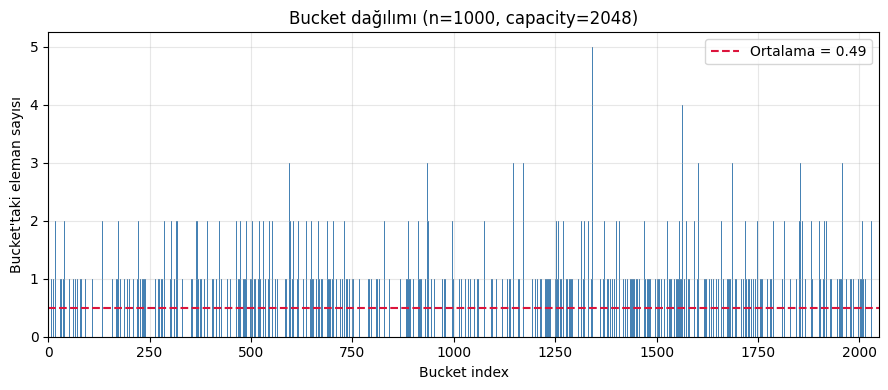

In [22]:
dist = big.bucket_distribution()
fig, ax = plt.subplots()
ax.bar(range(len(dist)), dist, color="steelblue", edgecolor="white")
ax.bar(range(len(dist)), dist, color="steelblue", width=1.0, linewidth=0)
ax.set_xlim(0, len(dist))
ax.set_xlabel("Bucket index")
ax.set_ylabel("Bucket'taki eleman sayısı")
ax.set_title(f"Bucket dağılımı (n={len(big)}, capacity={big._capacity})")
mean_per_bucket = len(big) / big._capacity
ax.axhline(mean_per_bucket, color="crimson", linestyle="--",
           label=f"Ortalama = {mean_per_bucket:.2f}")
ax.legend()
plt.tight_layout()
plt.show()


## 6) Karmaşıklık Analizi — Neden O(1) (Ortalama)?

### Sezgi: İyi Dağıtılmışsa Zincir Kısa Kalır

Tablo kapasitemiz `m`, eleman sayımız `n` olsun. İyi bir hash fonksiyonu elemanları bucket'lara **düzgün** dağıtıyorsa, her bucket'ta ortalama `n/m` eleman bulunur. Bu orana **yük faktörü (load factor)** diyoruz:

$$ \alpha = \frac{n}{m} $$

`put` veya `get` yaparken:
1. Hash hesapla — O(1)
2. Bucket'ı bul — O(1)
3. Bucket içindeki zinciri tara — O(α)

`α`'yı bir sabit (örn. ≤ 0.75) tutarsak, toplam O(1) olur. **Ama tabloyu büyütmezsek**, `α` büyür, zincirler uzar, her operasyon O(n)'e doğru yaklaşır. Bu yüzden **yeniden boyutlandırma (rehashing)** şart.

### En Kötü Durum: Kötü Hash veya Kötü Niyet

Eğer hash fonksiyonu **tüm anahtarları aynı bucket'a** yönlendirirse, tablo aslında bir bağlı listeye döner. Arama O(n). Bu teorik bir endişe değil: 2011'de PHP ve Java uygulamalarına karşı "**Hash Collision DoS**" saldırıları yapıldı — saldırganlar kasıtlı olarak çarpışan anahtarlar gönderip sunucuları dize aramaları içinde boğdular. Python 3.4'ten beri `hash()` içinde **SipHash** ile rastgele bir seed kullanılır; bu yüzden her program başlangıcında string hash'leri farklıdır.

### Tablo

| Operasyon | Ortalama (Average) | En Kötü (Worst) | Açıklama |
|-----------|---------------------|------------------|----------|
| `put`     | **O(1)**            | O(n)             | Rehash amortize edilir |
| `get`     | **O(1)**            | O(n)             | Zincir uzunluğuna bağlı |
| `delete`  | **O(1)**            | O(n)             | get + pop |
| `contains`| **O(1)**            | O(n)             | get ile aynı |
| İterasyon | O(n + m)            | O(n + m)         | Tüm bucket'ları dolaş |

### Alternatif Veri Yapılarıyla Kıyaslama

| Yapı | Ekleme | Arama | Silme | Sıralı Gezme | Bellek |
|------|--------|-------|-------|--------------|--------|
| Sıralanmamış liste | O(1) | O(n) | O(n) | O(n log n) | düşük |
| Sıralı dizi (binary search) | O(n) | O(log n) | O(n) | O(n) | düşük |
| BST (dengeli) | O(log n) | O(log n) | O(log n) | **O(n)** | orta |
| **Hash table** | **O(1)** | **O(1)** | **O(1)** | ❌ (sırasız) | orta–yüksek |

> 🎯 **Sticky Takeaway:** *Hash table, sıralamayı feda edip aramayı sabitleştirir.*


In [21]:
# Kendi HashTable'ımız vs Python dict vs list: 'in' operatörünün hızı

N = 50_000
keys = [f"key_{i}" for i in range(N)]
lookup_keys = random.sample(keys, 1000)  # aranacak 1000 anahtar

# 1) Python list (sıralanmamış) — beklenen: O(n) per lookup
py_list = list(keys)
_, t_list = timed(lambda: sum(1 for k in lookup_keys if k in py_list))

# 2) Python dict — built-in, C implementasyonu
py_dict = {k: i for i, k in enumerate(keys)}
_, t_dict = timed(lambda: sum(1 for k in lookup_keys if k in py_dict))

# 3) Bizim HashTable — saf Python, didaktik
ours = HashTable()
for k in keys:
    ours.put(k, 0)
_, t_ours = timed(lambda: sum(1 for k in lookup_keys if k in ours))

print(f"1000 aramanın toplam süresi ({N:,} eleman içinde):")
print(f"  Python list            : {t_list*1000:8.2f} ms")
print(f"  Bizim HashTable        : {t_ours*1000:8.2f} ms")
print(f"  Python dict (built-in) : {t_dict*1000:8.2f} ms")
print(f"\nHızlanma (list → dict) : {t_list / t_dict:,.0f}x")


1000 aramanın toplam süresi (50,000 eleman içinde):
  Python list            :   127.23 ms
  Bizim HashTable        :     0.76 ms
  Python dict (built-in) :     0.12 ms

Hızlanma (list → dict) : 1,084x


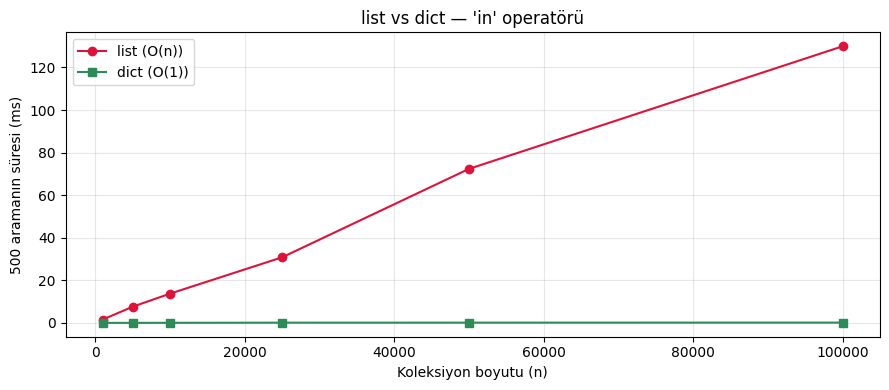

In [8]:
# Aynı benchmark'ı farklı N değerleri için tekrarlayıp görselleştir
sizes = [1_000, 5_000, 10_000, 25_000, 50_000, 100_000]
t_list_all, t_dict_all = [], []

for n in sizes:
    ks = [f"k_{i}" for i in range(n)]
    look = random.sample(ks, 500)
    lst = list(ks)
    dct = {k: 0 for k in ks}
    _, t1 = timed(lambda lst=lst, look=look: sum(1 for k in look if k in lst))
    _, t2 = timed(lambda dct=dct, look=look: sum(1 for k in look if k in dct))
    t_list_all.append(t1 * 1000)
    t_dict_all.append(t2 * 1000)

fig, ax = plt.subplots()
ax.plot(sizes, t_list_all, marker="o", label="list (O(n))", color="crimson")
ax.plot(sizes, t_dict_all, marker="s", label="dict (O(1))", color="seagreen")
ax.set_xlabel("Koleksiyon boyutu (n)")
ax.set_ylabel("500 aramanın süresi (ms)")
ax.set_title("list vs dict — 'in' operatörü")
ax.legend()
plt.tight_layout()
plt.show()


## 7) Algoritma: İki Toplam (Two Sum)

### Problem

> Bir tamsayı dizisi `nums` ve bir hedef sayı `target` verilsin. Toplamları `target`'a eşit olan **iki farklı elemanın indeksini** döndür.
>
> Örnek: `nums = [2, 7, 11, 15]`, `target = 9` → `(0, 1)` çünkü `2 + 7 = 9`.

### İlk Yaklaşım: Brute Force (Kaba Kuvvet) — O(n²)

En doğal fikir: tüm çiftleri dene. İki iç içe döngü. Dizi 10 elemanlı ise 100 deneme, 100.000 elemanlı ise 10 milyar — kabul edilemez.

### "Aha!" Anı — Hashmap ile O(n)

Diziyi **bir kez** dolaşırken her elemana bakıp soralım:

> *"Bu elemanla çift olabilmesi için ihtiyacım olan tamamlayıcı (complement) sayı nedir?"*
>
> Yani: `complement = target - current`
>
> Bu tamamlayıcıyı **daha önce** gördük mü? Eğer gördüysek, cevap bu.

"Daha önce gördüm mü?" sorusuna O(1)'de cevap verebilen bir yapı lazım. Tanıdık geldi mi? **Hashmap.**

### Pseudo-code

```
function two_sum(nums, target):
    seen = boş hashmap          # gördüğümüz sayı → indeksi
    her i, num çifti için nums içinde:
        complement = target - num
        eğer complement seen içinde ise:
            return (seen[complement], i)
        seen[num] = i          # bu sayıyı sonrası için kaydet
    return None                # çift bulunamadı
```

Kritik nokta: Mevcut elemanı **tamamlayıcıyı aradıktan sonra** kaydediyoruz. Bu sayede `nums[i] + nums[i] = target` olsa bile kendi kendiyle eşleşmeyiz.


In [14]:
def two_sum_brute(nums: list[int], target: int) -> tuple[int, int] | None:
    """Return indices (i, j) with nums[i] + nums[j] == target, or None. O(n^2)."""
    n = len(nums)
    for i in range(n):
        for j in range(i + 1, n):
            if nums[i] + nums[j] == target:
                return (i, j)
    return None


def two_sum_hashmap(nums: list[int], target: int) -> tuple[int, int] | None:
    """
    Single-pass hashmap solution. O(n) time, O(n) extra space.

    Invariant: before processing index i, `seen` contains all earlier values
    with their indices. We check for `target - nums[i]` before inserting `nums[i]`.
    """
    seen: dict[int, int] = {}  # değer -> ilk görüldüğü indeks
    for i, num in enumerate(nums):
        complement = target - num
        if complement in seen:
            return (seen[complement], i)
        seen[num] = i
    return None


# Çalışan örnekler
print("Örnek 1:", two_sum_hashmap([2, 7, 11, 15], 9))       # (0, 1)
print("Örnek 2:", two_sum_hashmap([3, 2, 4], 6))            # (1, 2)
print("Örnek 3:", two_sum_hashmap([3, 3], 6))               # (0, 1) — aynı değer, farklı indeks
print("Örnek 4:", two_sum_hashmap([1, 2, 3], 100))          # None — çözüm yok
print("Örnek 5:", two_sum_hashmap([], 0))                    # None — boş dizi


Örnek 1: (0, 1)
Örnek 2: (1, 2)
Örnek 3: (0, 1)
Örnek 4: None
Örnek 5: None


### İki Yaklaşım Arasındaki Farkı Hisset

Aşağıdaki benchmark, dizi boyutu büyüdükçe iki algoritmanın süresinin **nasıl uçuruma dönüştüğünü** gösterir.


n=   500 | brute=    4.18 ms | hash=  0.08 ms | speedup=53x
n= 1,000 | brute=   15.78 ms | hash=  0.11 ms | speedup=139x
n= 2,000 | brute=   56.77 ms | hash=  0.60 ms | speedup=95x
n= 5,000 | brute=  367.41 ms | hash=  0.62 ms | speedup=591x
n=10,000 | brute= 1626.98 ms | hash=  0.95 ms | speedup=1,719x


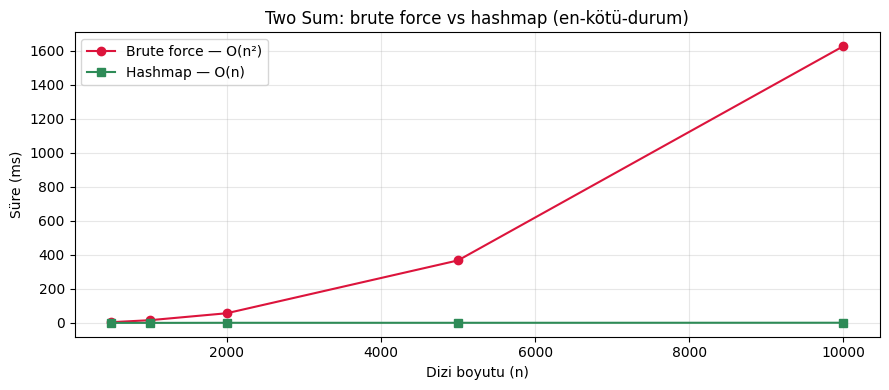

In [20]:
sizes = [500, 1_000, 2_000, 5_000, 10_000]
brute_times, hash_times = [], []

for n in sizes:

    nums = random.sample(range(-10 * n, 10 * n, 2), n)   # sadece çift sayı
    target = 1                                            # tek → erişilemez

    _, tb = timed(two_sum_brute, nums, target)
    _, th = timed(two_sum_hashmap, nums, target)
    brute_times.append(tb * 1000)
    hash_times.append(th * 1000)
    print(f"n={n:>6,} | brute={tb*1000:8.2f} ms | hash={th*1000:6.2f} ms | speedup={tb/th:,.0f}x")

fig, ax = plt.subplots()
ax.plot(sizes, brute_times, marker="o", label="Brute force — O(n²)", color="crimson")
ax.plot(sizes, hash_times, marker="s", label="Hashmap — O(n)", color="seagreen")
ax.set_xlabel("Dizi boyutu (n)")
ax.set_ylabel("Süre (ms)")
ax.set_title("Two Sum: brute force vs hashmap (en-kötü-durum)")
ax.legend()
plt.tight_layout()
plt.show()

## 8) Neden Bu Kadar Önemli? — Gerçek Dünyadan Örnekler

Hashmap sadece bir ders konusu değil. Günde milyarlarca kez çalıştırdığın sistemlerin çekirdeğinde var:

### 1. Python'un `dict`'i — Her Satırının Altında
Python'da bir fonksiyon çağırdığında (`obj.method()`), Python aslında arka planda bir dict lookup yapıyor: "method" adı → kod objesi. Modül importları, global değişkenler, class attribute'ları — hepsi dict. CPython, 3.6'dan itibaren **compact dict** optimizasyonuyla insertion order'ı da koruyor, ama yapı hâlâ özünde bir hash table.

### 2. Git'in Nesne Deposu — Content-Addressed Storage
Git, her commit'i, her dosyayı, her ağacı (tree) **SHA-1 hash**'ine göre saklar. Yani dosyanın içeriği kendi adresidir. `git show a1b2c3d` dediğinde, Git o hash'i hash table'da arar. Aynı içeriğe sahip iki dosya iki kez saklanmaz — **hash ile deduplikasyon**.

### 3. Veritabanı İndeksleri — Hash Index
PostgreSQL, MySQL, Oracle — hepsinde **hash index** seçeneği vardır. B-tree index aralık sorgularında (`WHERE age BETWEEN 20 AND 30`) daha iyiyken, eşitlik sorgularında (`WHERE email = 'x@y.com'`) hash index O(1) ile kazanır. Redis zaten tamamen bir hash table'dır — anahtar-değer deposu.

### 4. Derleyiciler — Symbol Tables
Bir değişken tanımladığında (`int x = 5;`), derleyici `x`'i bir **symbol table**'a yazar. Kodun ilerisinde `x` geçtiğinde hash lookup ile anlamını bulur. Hashmap olmadan modern derleyici yazılamazdı.

### 5. Web Sunucularında Caching — Memcached, Redis
Popüler siteler her isteği tekrar tekrar veritabanına göndermez. Önce cache'e bakarlar: "Bu kullanıcının profilini hafızada tutuyor muyum?" — bu soru bir hashmap lookup'ı. Facebook'un **TAO (The Associations and Objects)** sistemi, Twitter'ın timeline'ı, hepsinin altında ünde hashmap yatıyor.

### 6. Bloom Filters — "Olmadığından Eminim"
Hashmap'in kuzeni: çoklu hash fonksiyonlarıyla çalışan bir bit dizisi. "Bu kullanıcı adı alındı mı?" sorusuna %99 kesinlikle "hayır" diyebilir, "evet" dediğinde ise gerçek bir kontrol tetiklenir. Chrome'un "güvensiz URL" listesi bu fikir üzerine kurulu.


## 9) Yaygın Hatalar ve Tuzaklar

### Hata 1: Mutable (Değiştirilebilir) Nesneyi Anahtar Yapmak
```python
d = {}
key = [1, 2, 3]   # liste mutable
d[key] = "x"      # TypeError: unhashable type: 'list'
```
**Neden yanlış?** Hashmap, anahtarın hash'ini slot bulmak için kullanır. Anahtar sonradan değişirse, aynı nesne farklı bir bucket'a ait olması gerekir — ama nesneyi bulman imkansızlaşır. Python da bunu en baştan yasaklar.

**Düzeltme:** Immutable (değiştirilemez) tipler kullan: `tuple`, `str`, `int`, `frozenset`.

### Hata 2: Hash Fonksiyonunu `__eq__` ile Uyumsuz Tanımlamak
Kendi sınıfını yazıp `__hash__` verip `__eq__`'i unutursan (veya tam tersi), hash table `x == y` olup `hash(x) != hash(y)` olan iki nesneyi ayrı slot'lara koyar — tablo bozulur.

**Kural (Python resmi):** `a == b` ⇒ `hash(a) == hash(b)`. Tersi şart değil.

### Hata 3: Her Zaman O(1) Varsaymak
Saldırganın anahtarları seçebildiği veya hash fonksiyonunun kötü olduğu bir ortamda, hash table O(n)'e çöker. Yönetici paneline gelen request'lerin parametrelerinden dict oluşturuyorsan, bunu düşünmen gerek.

**Düzeltme:** Güvenlik-kritik contextlerde **rastgele tohumlu (randomized) hash** veya **treap** gibi yapılar kullan. Python 3.4+ bunu zaten string'ler için yapıyor.

### Hata 4: Silme Sırasında İterasyon
```python
for k in d:          # RuntimeError: dictionary changed size during iteration
    if k.startswith("tmp_"):
        del d[k]
```
**Düzeltme:** Önce silinecekleri topla, sonra sil:
```python
to_delete = [k for k in d if k.startswith("tmp_")]
for k in to_delete:
    del d[k]
```


In [16]:
# Hata 2'yi canlı görelim: __hash__ ve __eq__ uyumsuz olursa...

class BrokenKey:
    def __init__(self, name: str):
        self.name = name

    def __hash__(self) -> int:
        # Kötü niyetle her nesneye farklı hash
        return id(self)

    def __eq__(self, other: object) -> bool:
        # ama eşitliği isme göre yap
        return isinstance(other, BrokenKey) and self.name == other.name


d: dict[BrokenKey, str] = {}
d[BrokenKey("x")] = "ilk"
d[BrokenKey("x")] = "ikinci"  # aynı 'isim' ama farklı hash
print(f"dict boyutu (beklenen 1, gerçek): {len(d)}")  # beklenti kırık!
print("Dict içeriği:", {k.name: v for k, v in d.items()})


dict boyutu (beklenen 1, gerçek): 2
Dict içeriği: {'x': 'ikinci'}


## 10) Mini Alıştırmalar

### 🟢 Kolay — İki Dizide Ortak Elemanlar (Intersection)

İki tamsayı listesi verilsin. Her iki listede de bulunan elemanları (tekrar etmeden) döndür. O(n + m) hedefle.

```python
def intersection(a: list[int], b: list[int]) -> list[int]:
    ...
```

Örnek:
```
intersection([1, 2, 2, 3], [2, 3, 4]) → [2, 3]   # sıra önemli değil
```


In [12]:
# Çözüm (hidden) — Kolay

def intersection(a: list[int], b: list[int]) -> list[int]:
    """Return the set intersection of two lists. O(n + m) time, O(n) space."""
    # a'nın elemanlarını bir set'e koy → O(1) lookup
    seen = set(a)
    result: set[int] = set()
    for x in b:
        if x in seen:
            result.add(x)
    return sorted(result)


assert intersection([1, 2, 2, 3], [2, 3, 4]) == [2, 3]
assert intersection([], [1, 2]) == []
assert intersection([1, 1, 1], [1, 1]) == [1]
print("Kolay ✓")


Kolay ✓


## 11) Özet — Akılda Kalacak Üç Şey

> 🎯 **1. Arama yerine hesaplama.** Hash table, "bu anahtar nerede?" sorusunu "anahtardan yeri **hesapla**" sorusuna çevirir. Arama O(n)'den O(1)'e iner.
>
> 🎯 **2. O(1) ortalamadır, garanti değildir.** İyi bir hash fonksiyonu + sağlıklı yük faktörü olduğunda O(1). Kötü hash veya kasıtlı çarpışma olursa O(n). Güvenlik ve performans beraber düşünülmeli.
>
> 🎯 **3. Her `in` sorusunda hashmap'i hatırla.** Two Sum, ortak elemanlar, sık geçenler, tekrarsız alt dize... Bir problemde "daha önce X'i gördüm mü?" sorusu varsa, cevap büyük olasılıkla hashmap.


---

### 📚 Ek Kaynaklar
- Donald Knuth, *The Art of Computer Programming*, Vol. 3, §6.4 (Hashing)
- *Introduction to Algorithms* (CLRS), Ch. 11
- Python source code: [`cpython/Objects/dictobject.c`](https://github.com/python/cpython/blob/main/Objects/dictobject.c) — compact dict'in gerçek implementasyonu
- Raymond Hettinger, *"Modern Python Dictionaries"* konuşması (YouTube)

---
*fmsimav/DSA2026
